IMPORT LIBRARIES

In [42]:
import matplotlib.pyplot as plt  # Used for plotting graphs like bar charts, line plots, etc.
import seaborn as sns  # Makes plots prettier and easier to read
import time  # To measure how long parts of the code take to run
from sklearn.metrics import confusion_matrix  # To see how well the model predicts
import joblib  # To save and load trained models
import pandas as pd  # For working with data in tables (dataframes)
import numpy as np  # For numerical calculations and array operations
import warnings  # To control warning messages
warnings.filterwarnings("ignore")  # Ignore warnings so output is cleaner

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score  # For splitting data and cross-validation
from sklearn.pipeline import Pipeline  # Helps chain preprocessing and model in one step
from sklearn.impute import SimpleImputer  # To fill missing values automatically
from sklearn.metrics import (  # Import evaluation metrics
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_score, recall_score,
    fbeta_score, make_scorer, accuracy_score, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression  # Logistic Regression model
from xgboost import XGBClassifier  # XGBoost model for high-performance classification
from openpyxl import load_workbook  # To read/write Excel files
from openpyxl.styles import PatternFill  # To highlight cells in Excel

LOAD DATASETS

In [43]:
train = pd.read_csv("../data/train.csv")  # Load main training data
geo = pd.read_csv("../data/Geo_scores.csv")  # Load geography-based features
qset = pd.read_csv("../data/Qset_tats.csv")  # Load questionnaire statistics
inst = pd.read_csv("../data/instance_scores.csv")  # Load instance-specific scores
lambda_wts = pd.read_csv("../data/Lambda_wts.csv")  # Load group-level weights

EDA(Exploratory Data Analysis)

In [44]:
print("---- HEAD OF TRAIN ----")# Display the first 5 rows of the dataset.
print(train.head(), "\n")

---- HEAD OF TRAIN ----
       id   Group      Per1      Per2      Per3      Per4      Per5      Per6  \
0  112751  Grp169  1.070000  0.580000  0.480000  0.766667  1.233333  1.993333   
1   18495  Grp161  0.473333  1.206667  0.883333  1.430000  0.726667  0.626667   
2   23915  Grp261  1.130000  0.143333  0.946667  0.123333  0.080000  0.836667   
3   50806  Grp198  0.636667  1.090000  0.750000  0.940000  0.743333  0.346667   
4  184244  Grp228  0.560000  1.013333  0.593333  0.416667  0.773333  0.460000   

       Per7      Per8  ...      Dem8      Dem9     Cred1     Cred2     Cred3  \
0  0.340000  1.010000  ...  0.680000  0.726667  0.606667  1.010000  0.933333   
1  0.810000  0.783333  ...  0.716667  0.743333  0.680000  0.690000  0.560000   
2  0.056667  0.756667  ...  0.690000  0.820000  0.600000  0.383333  0.763333   
3  0.956667  0.633333  ...  0.720000  0.900000  0.680000  0.846667  0.423333   
4  0.853333  0.796667  ...  0.603333  0.486667  0.693333  0.526667  0.520000   

      Cr

In [45]:
print("---- INFO ----")# Shows column-wise information and helps us identify missing values and datatype issues early.
print(train.info(), "\n")

---- INFO ----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227845 entries, 0 to 227844
Data columns (total 28 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              227845 non-null  int64  
 1   Group           227845 non-null  object 
 2   Per1            227845 non-null  float64
 3   Per2            227845 non-null  float64
 4   Per3            227845 non-null  float64
 5   Per4            227845 non-null  float64
 6   Per5            227845 non-null  float64
 7   Per6            227845 non-null  float64
 8   Per7            227845 non-null  float64
 9   Per8            227845 non-null  float64
 10  Per9            227845 non-null  float64
 11  Dem1            227845 non-null  float64
 12  Dem2            227845 non-null  float64
 13  Dem3            227845 non-null  float64
 14  Dem4            227845 non-null  float64
 15  Dem5            227845 non-null  float64
 16  Dem6            227845 non-null  float64


In [46]:
print("---- DESCRIPTION ----")# Provides statistical summary for numerical columns and helps in understanding value ranges and spotting outliers.
print(train.describe(), "\n")

---- DESCRIPTION ----
                  id           Per1           Per2           Per3  \
count  227845.000000  227845.000000  227845.000000  227845.000000   
mean   142404.076201       0.666006       0.667701       0.666315   
std     82170.248170       0.654133       0.548305       0.506357   
min         0.000000     -18.136667     -23.573333     -15.443333   
25%     71325.000000       0.360000       0.470000       0.370000   
50%    142374.000000       0.670000       0.690000       0.726667   
75%    213492.000000       1.103333       0.933333       1.010000   
max    284805.000000       1.483333       8.020000       3.793333   

                Per4           Per5           Per6           Per7  \
count  227845.000000  227845.000000  227845.000000  227845.000000   
mean        0.666687       0.666723       0.667378       0.666934   
std         0.471956       0.461393       0.444573       0.415657   
min        -1.226667     -37.246667      -8.053333     -13.853333   
25%        

---- TARGET DISTRIBUTION ----
Target
0    227451
1       394
Name: count, dtype: int64 



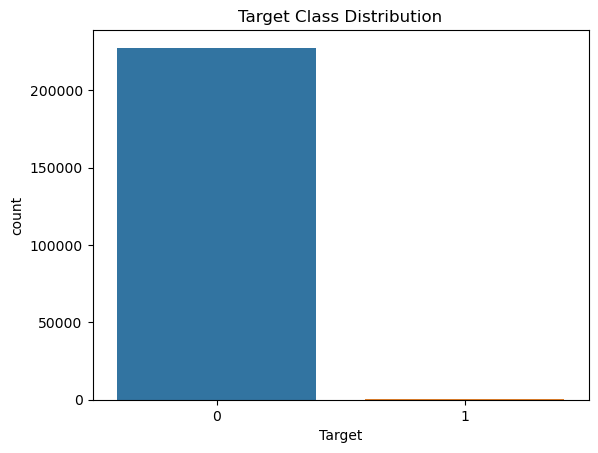

In [47]:
# Class balance check
print("---- TARGET DISTRIBUTION ----")# Fraud datasets are usually highly imbalanced so helps us understand how many fraud vs non-fraud cases are present.
print(train['Target'].value_counts(), "\n")
sns.countplot(x='Target', data=train)
plt.title("Target Class Distribution")
plt.show()

In [48]:
# Missing values check
print("---- MISSING VALUES ----")# Checking missing values in each column.
print(train.isna().sum(), "\n")

---- MISSING VALUES ----
id                0
Group             0
Per1              0
Per2              0
Per3              0
Per4              0
Per5              0
Per6              0
Per7              0
Per8              0
Per9              0
Dem1              0
Dem2              0
Dem3              0
Dem4              0
Dem5              0
Dem6              0
Dem7              0
Dem8              0
Dem9              0
Cred1             0
Cred2             0
Cred3             0
Cred4             0
Cred5             0
Cred6             0
Normalised_FNT    0
Target            0
dtype: int64 



DATA CLEANING AND AGGREGATION

In [49]:
# Clean Geo dataset
geo["id"] = pd.to_numeric(geo["id"], errors="coerce")  # Convert ID to numeric; invalid ones become NaN
geo.dropna(subset=["id"], inplace=True)  # Remove rows where ID is missing
geo["id"] = geo["id"].astype(int)  # Make sure ID is integer
geo = geo.groupby("id").mean().reset_index()  # Aggregate rows with same ID by taking mean

In [50]:
# Clean Qset dataset
qset["id"] = pd.to_numeric(qset["id"], errors="coerce")  # Convert ID to numeric
qset.dropna(subset=["id"], inplace=True)  # Remove missing IDs
qset["id"] = qset["id"].astype(int)  # Ensure ID is integer
qset = qset.groupby("id").mean().reset_index()  # Aggregate rows by mean for same ID

In [51]:
# Clean Inst dataset
inst["id"] = pd.to_numeric(inst["id"], errors="coerce")  # Convert ID to numeric
inst.dropna(subset=["id"], inplace=True)  # Remove missing IDs
inst["id"] = inst["id"].astype(int)  # Ensure ID is integer
inst = inst.groupby("id").mean().reset_index()  # Aggregate duplicate IDs

In [52]:
# Clean Train dataset
train["id"] = pd.to_numeric(train["id"], errors="coerce")  # Convert ID to numeric
train.dropna(subset=["id", "Target"], inplace=True)  # Remove rows with missing ID or Target
train["id"] = train["id"].astype(int)  # Make ID integer
train["Target"] = train["Target"].astype(int)  # Ensure Target is integer

MERGE DATASETS

In [53]:
df = train.merge(geo, on="id", how="left")  # Merge geo features into train
df = df.merge(qset, on="id", how="left")  # Merge questionnaire features
df = df.merge(inst, on="id", how="left")  # Merge instance features
# Merge Lambda weights if "Group" column exists
if "Group" in df.columns:
    df = df.merge(lambda_wts, on="Group", how="left")  # Merge group-level weights
    df.drop(columns=["Group"], inplace=True)  # Drop Group column after merging

FEATURE AND TARGET SEPARATION

In [58]:
X = df.drop(columns=["id", "Target"])  # Features for model
y = df["Target"]  # Target variable we want to predict

TRAIN-TEST SPLIT

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42  # Split data 80-20; maintain class balance
)


In [60]:
# Calculate positive class weight for XGBoost (imbalanced dataset handling)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # Ratio of negative to positive samples

PIPELINE BUILDING

In [61]:
# Logistic Regression pipeline
logistic_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # Fill missing values with median
    ("model", LogisticRegression(
        class_weight="balanced",  # Automatically handle class imbalance
        max_iter=1000,  # Allow more iterations for convergence
        solver="liblinear",  # Good solver for small datasets
        random_state=42  # Reproducibility
    ))
])
# XGBoost pipeline
xgb_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # Fill missing values
    ("model", XGBClassifier(
        scale_pos_weight=pos_weight,  # Handle class imbalance
        eval_metric="logloss",  # Use logloss to evaluate performance
        use_label_encoder=False,  # Avoid warnings for old label encoding
        random_state=42,  # Reproducible results
        n_jobs=-1,  # Use all CPU cores
        max_depth=6,  # Allow deeper trees to capture patterns
        learning_rate=0.05,  # Smaller learning rate for better generalization
        n_estimators=500,  # Number of trees
        subsample=0.8,  # Random subset of rows for each tree
        colsample_bytree=0.8  # Random subset of columns for each tree
    ))
])

CROSS-VALIDATION

In [62]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold CV, keep class distribution

In [63]:
# Logistic Regression Cross-Validation
log_acc = cross_val_score(logistic_pipe, X_train, y_train, cv=kf, scoring=make_scorer(accuracy_score))  # CV accuracy
log_roc = cross_val_score(logistic_pipe, X_train, y_train, cv=kf, scoring="roc_auc")  # CV ROC-AUC
log_pr = cross_val_score(logistic_pipe, X_train, y_train, cv=kf, scoring="average_precision")  # CV AUPRC

In [64]:
# XGBoost Cross-Validation
xgb_acc = cross_val_score(xgb_pipe, X_train, y_train, cv=kf, scoring=make_scorer(accuracy_score))  # CV accuracy
xgb_roc = cross_val_score(xgb_pipe, X_train, y_train, cv=kf, scoring="roc_auc")  # CV ROC-AUC
xgb_pr = cross_val_score(xgb_pipe, X_train, y_train, cv=kf, scoring="average_precision")  # CV AUPRC

In [65]:
print(f"Logistic | Accuracy: {log_acc.mean():.4f} | ROC-AUC: {log_roc.mean():.4f} | AUPRC: {log_pr.mean():.4f}")  # Show logistic CV metrics
print(f"XGBoost  | Accuracy: {xgb_acc.mean():.4f} | ROC-AUC: {xgb_roc.mean():.4f} | AUPRC: {xgb_pr.mean():.4f}")  # Show XGB CV metrics

Logistic | Accuracy: 0.9740 | ROC-AUC: 0.9707 | AUPRC: 0.7135
XGBoost  | Accuracy: 0.9995 | ROC-AUC: 0.9718 | AUPRC: 0.8439


FIT MODELS ON TRAINING DATA

In [66]:
logistic_pipe.fit(X_train, y_train)  # Train Logistic Regression on full train set
xgb_pipe.fit(X_train, y_train)  # Train XGBoost on full train set

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=500, n_jobs=-1,
                               num_parallel_tree=None, ...))])

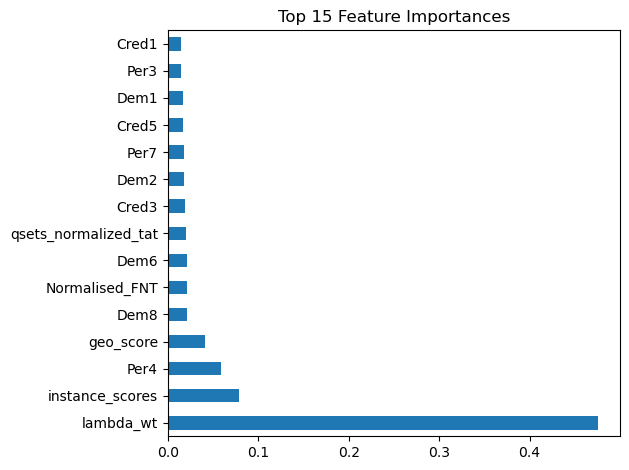

In [67]:
feat_imp = pd.Series(xgb_pipe.named_steps['model'].feature_importances_, index=X_train.columns)  # Extract feature importance scores from the trained XGBoost model inside the pipeline and map them to their column names
feat_imp.nlargest(15).plot(kind='barh', title='Top 15 Feature Importances')  # Select top 15 most important features and plot them as a horizontal bar chart
plt.tight_layout()  # Adjust spacing so labels and title don't get cut off
plt.show()  # Display the plot

PREDICT PROBABILITIES ON TEST SET

In [68]:
log_probs = logistic_pipe.predict_proba(X_test)[:, 1]  # Get predicted probabilities for positive class
xgb_probs = xgb_pipe.predict_proba(X_test)[:, 1]  # Get predicted probabilities for positive class

CUSTOM EVALUATION FUNCTION

In [69]:
def evaluate_model(name, probs):
    precision, recall, thresholds = precision_recall_curve(y_test, probs)  # Get precision-recall curve
    f2 = (5 * precision * recall) / (4 * precision + recall + 1e-9)  # F2-score: recall weighted more
    idx = np.argmax(f2)  # Index of threshold with best F2-score
    preds = (probs >= thresholds[idx]).astype(int)  # Convert probabilities to binary predictions
    cm = confusion_matrix(y_test, preds)  # Confusion matrix
    return {  # Return all metrics in a dictionary
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
        "AUPRC": average_precision_score(y_test, probs),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F2-Score": fbeta_score(y_test, preds, beta=2),
        "TP": cm[1, 1],
        "FP": cm[0, 1],
        "Threshold": thresholds[idx]
    }

EVALUATE MODELS

In [70]:
log_res = evaluate_model("Logistic", log_probs)  # Evaluate Logistic Regression
xgb_res = evaluate_model("XGBoost", xgb_probs)  # Evaluate XGBoost
results_df = pd.DataFrame([log_res, xgb_res]).sort_values("F2-Score", ascending=False)  # Creates summary table
print(results_df)  # Show final metrics

      Model  Accuracy   ROC-AUC     AUPRC  Precision    Recall  F2-Score  TP  \
1   XGBoost  0.999583  0.972642  0.827060   0.954545  0.797468  0.824607  63   
0  Logistic  0.999386  0.968229  0.723434   0.869565  0.759494  0.779221  60   

   FP  Threshold  
1   3   0.520317  
0   9   0.999999  


MEASURE RESPONSE TIME

In [71]:
start = time.time()  # Start timer
logistic_pipe.predict(X_test)  # Make predictions on test set
log_time = time.time() - start  # Calculate how long it took

start = time.time()  # Start timer again
xgb_pipe.predict(X_test)  # Make predictions on test set
xgb_time = time.time() - start  # Calculate how long it took

results_df['Response Time (s)'] = [log_time, xgb_time]  # Add response time to results table

PLOTTING COMPARATIVE METRICS

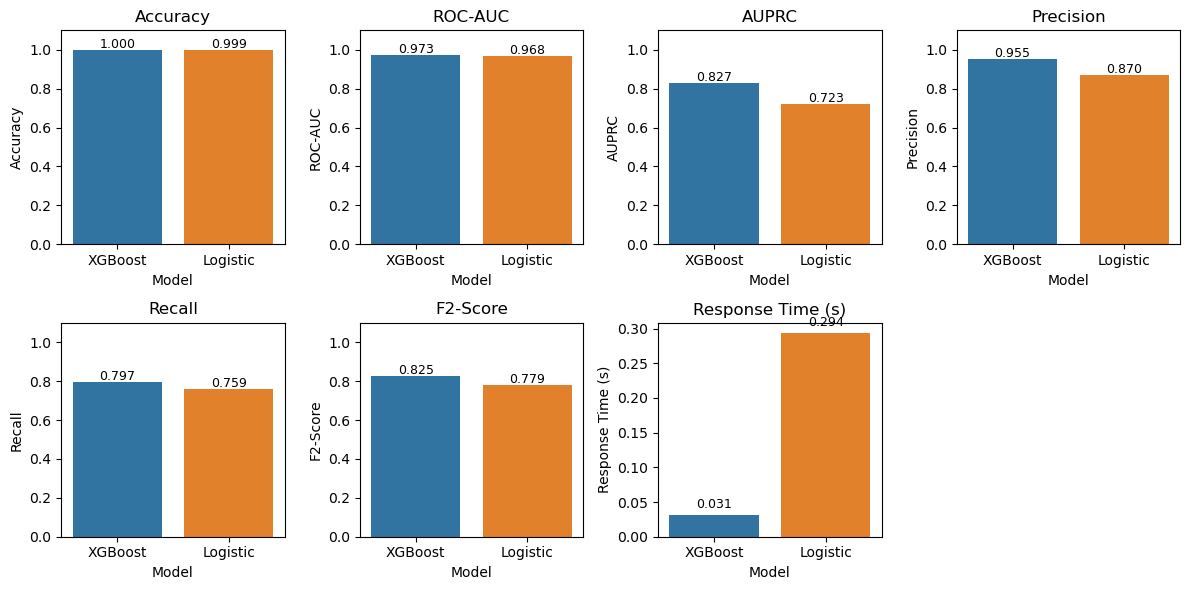

In [72]:
metrics = ["Accuracy", "ROC-AUC", "AUPRC", "Precision", "Recall", "F2-Score", "Response Time (s)"]  # Metrics to compare
plt.figure(figsize=(12,6))  # Set figure size
for i, metric in enumerate(metrics, 1):  # Loop through metrics
    plt.subplot(2, 4, i)  # Create subplots
    sns.barplot(x='Model', y=metric, data=results_df)  # Bar chart of metric for each model
    plt.title(metric)  # Title of subplot
    plt.ylim(0, 1.1 if metric != "Response Time (s)" else None)  # Set y-limit for scores, skip for time
    for idx, val in enumerate(results_df[metric]):  # Annotate bars with values
        plt.text(idx, val + 0.01, f"{val:.3f}", ha='center', fontsize=9)
plt.tight_layout()  # Adjust layout so plots don't overlap
plt.show()  # Show plots

CONFUSION MATRIX

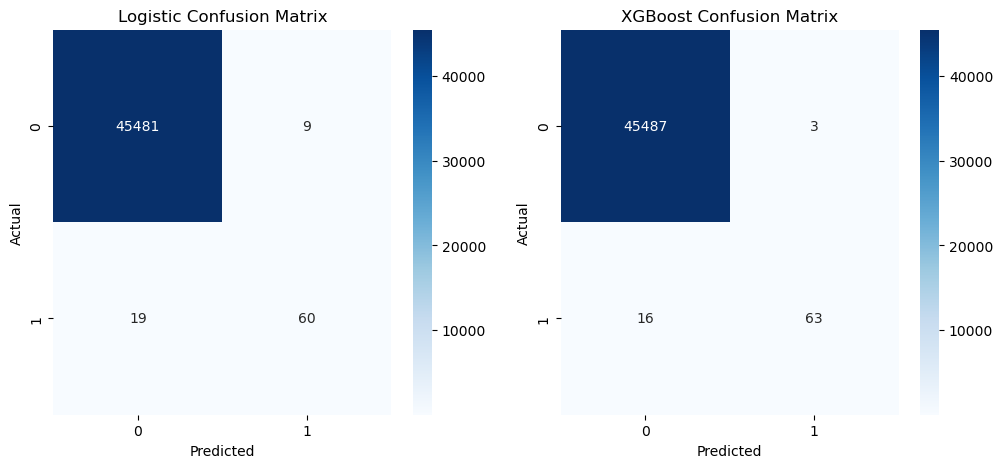

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))  # Create two subplots side by side
for ax, model, probs in zip(axes, ["Logistic", "XGBoost"], [log_probs, xgb_probs]):
    threshold = results_df.loc[results_df['Model']==model, 'Threshold'].values[0]  # Get best threshold for model
    preds = (probs >= threshold).astype(int)  # Convert probabilities to binary predictions
    cm = confusion_matrix(y_test, preds)  # Get confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)  # Plot heatmap with annotations
    ax.set_title(f"{model} Confusion Matrix")  # Set title
    ax.set_xlabel("Predicted")  # Label x-axis
    ax.set_ylabel("Actual")  # Label y-axis
plt.show() 

PREPARING TEST DATA

In [74]:
best_model_name = results_df.iloc[0]["Model"]  # Choose best model based on F2-Score
best_threshold = results_df.iloc[0]["Threshold"]  # Best threshold for classification
best_pipeline = xgb_pipe if best_model_name == "XGBoost" else logistic_pipe  # Select best trained pipeline

test_share = pd.read_csv("../data/test_share.csv")  # Load test data for final prediction

test_share["id"] = pd.to_numeric(test_share["id"], errors="coerce")  # Convert ID to numeric
test_share.dropna(subset=["id"], inplace=True)  # Drop rows with missing IDs
test_share["id"] = test_share["id"].astype(int)  # Make sure ID is integer

In [75]:
# Merge features from other datasets like we did for training
test_df = test_share.merge(geo, on="id", how="left")  # Merge geo features
test_df = test_df.merge(qset, on="id", how="left")  # Merge questionnaire features
test_df = test_df.merge(inst, on="id", how="left")  # Merge instance features

In [76]:
if "Group" in test_df.columns:  # If Group column exists
    test_df = test_df.merge(lambda_wts, on="Group", how="left")  # Merge group weights
    test_df.drop(columns=["Group"], inplace=True)  # Drop Group after merge
X_client = test_df.drop(columns=["id"])  # Keep only features for prediction
client_probs = best_pipeline.predict_proba(X_client)[:, 1]  # Predict probabilities for positive class
client_preds = (client_probs >= best_threshold).astype(int)  # Convert probabilities to binary predictions
final_output = pd.DataFrame({  # Prepare final output for Excel
    "id": test_df["id"],
    "Fraud_Prediction": client_preds
})

In [77]:
excel_path = "../model/test_share_predictions.xlsx"  # Path to save Excel file
final_output.to_excel(excel_path, index=False)  # Save predictions to Excel

In [78]:
# Highlight Fraud in Excel
wb = load_workbook(excel_path)  # Open Excel file
ws = wb.active  # Get the active sheet
yellow = PatternFill(start_color="FFFF00", end_color="FFFF00", fill_type="solid")  # Yellow fill style
for row in range(2, ws.max_row + 1):  # Loop through all rows except header
    if ws.cell(row=row, column=2).value == 1:  # If prediction is fraud (1)
        ws.cell(row=row, column=2).fill = yellow  # Highlight cell in yellow
wb.save(excel_path)  # Save changes to Excel

SAVING MODEL

In [79]:
joblib.dump(best_pipeline, "../model/best_fraud_pipeline.pkl")  # Save the trained model for later use

['../model/best_fraud_pipeline.pkl']

In [80]:
print(f"Best Model Selected: {best_model_name}")  # Show which model was selected as best
print(f"Final Excel file saved with fraud highlighted: {excel_path}")  # Confirm Excel output
print("..........DONE..........")  # Indicate MODEL pipeline is done

Best Model Selected: XGBoost
Final Excel file saved with fraud highlighted: ../model/test_share_predictions.xlsx
..........DONE..........


In [81]:
import os
print(os.listdir("../model"))

['best_fraud_pipeline.pkl', 'test_share_predictions.xlsx']
